In [1]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.anchored_artists import AnchoredSizeBar
import matplotlib.font_manager as fm
from matplotlib.patches import Ellipse
from scipy import ndimage
from scipy.optimize import curve_fit
from scipy.interpolate import interp1d, interp2d
import os
import sys
import corner
from radmc3dPy import image
from radmc3dPy.analyze import *
# from CB68.data_dict import data_dict
from make_conti import generate_model
sys.path.append("..")
from profile_radial.make_disk import generate_disk
sys.path.insert(0,'../../')
from CB68.data_dict import data_dict


from astropy.io import fits
from astropy.wcs import WCS
from astropy.wcs.utils import skycoord_to_pixel
from astropy.coordinates import SkyCoord
import astropy.constants as const
au = const.au.cgs.value
pc = const.pc.cgs.value



Fast (Fortran90) Mie-scattering module could not be imported. Falling back to the slower Python version.


In [2]:
sizeau = 80
npix = 500
pixel_area = (sizeau/npix/140)**2
beam_axis = [0.0363, 0.0274]
beam_area = beam_axis[0]*beam_axis[1]*np.pi/(4*np.log(2))
r_axis = np.linspace(-(sizeau//2), sizeau//2, npix, endpoint=True)

In [3]:
edisk_radial = np.load("edisk_radial.npz")
i_r_obs = edisk_radial["i_r"]

In [4]:
def rotate_image(image, posang):
  if isinstance(image, np.ndarray)!=True:
    image.imageJyppix= ndimage.rotate(image.imageJyppix, posang, reshape=False, axes=(1, 0))
    image.imageJyppix = np.nan_to_num(image.imageJyppix, nan=0)
    return image.imageJyppix[:,:,0]
  else:
    image = ndimage.rotate(image, posang, reshape=False, axes=(1, 0))
    image = np.nan_to_num(image, nan=0)
    return image

def radial_intensity(image_array, center, width):
  if center is None:
    peak_idx_x, peak_idx_y = np.unravel_index(np.argmax(image_array, axis=None), image_array.shape)
    center = peak_idx_y
  radial_profile = np.mean(image_array[:, center-width//2:center+width//2], axis=1)
  return radial_profile

def get_radial_profile(image, beam_axis, posang=45, center=None, width=10):
  conv_image = image.imConv(dpc=140, fwhm=beam_axis, pa=-69.4)
  conv_image = rotate_image(conv_image, posang)
  conv_image *= beam_area/pixel_area/(140**2)
  i_r = radial_intensity(conv_image, center, width)
  return i_r

def chi(i_r_model, i_r_obs):
    if len(i_r_model) != len(i_r_obs):
        interp_func = interp1d(np.linspace(0, 1, len(i_r_model)), i_r_model, kind='cubic')
        i_r_model = interp_func(np.linspace(0, 1, len(i_r_obs)))
    return np.sum(((i_r_model - i_r_obs)**2)/(21e-6**2))

def plot_i_r(i_r_model, a, L_star, Q, mdot, heat='radiation'):
    plt.plot(r_axis, i_r_model*1e3, label=" radiation model")
    plt.plot(edisk_radial["r_axis"], edisk_radial["i_r"]*1e3, label="eDisk", linestyle="--")
    plt.xlim((-(sizeau//2), sizeau//2))
    plt.ylim(bottom=0)
    plt.xlabel("Offset (AU)")
    plt.ylabel("Intensity (mJy/beam)")
    plt.title(f"Continuum radial profile along the major axis")
    plt.legend()
    plt.savefig(f"./figures/i_r/{heat}/a_{a}_Lstar_{L_star}_Q_{Q}_mdot_{mdot}_{heat}.pdf", transparent=True)
    plt.close("all")

def plot_image(image, beam_axis, posang, a, L_star, Q, mdot, heat='radiation'):
    conv_image = image.imConv(dpc=140, fwhm=beam_axis, pa=-69.4)
    conv_image = rotate_image(conv_image, posang)
    conv_image *= beam_area/pixel_area/(140**2)
    plt.imshow(conv_image.T, origin='lower', cmap="inferno", vmin=10*21e-6)
    plt.colorbar()
    plt.savefig(f"./figures/image/{heat}/a_{a}_Lstar_{L_star}_Q_{Q}_mdot_{mdot}_{heat}.pdf", transparent=True)
    plt.close("all")


def read_from_dir(dir):
    os.chdir(dir)
    d = readData(dtemp=True, ddens=True, gdens=True, ispec='ch3oh')
    grid = readGrid(wgrid=False)
    os.chdir('..')
    return d, grid

def plot_profile(d, grid):
    nch3oh    = d.ndens_mol[:, :, 0, 0]
    dust      = np.sum(d.rhodust[:, :, 0, :], axis=2)
    t         = np.mean(d.dusttemp[:, :, 0, :], axis=2)
    R, Theta, Phi =  grid.x/au, grid.y, grid.z
    fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(18, 6),
                        subplot_kw={'projection': 'polar'})
    fig.subplots_adjust(left=0.05, right=0.95, top=0.9, bottom=0.1, wspace=0.3, hspace=0.05)
    cmaps = ['BuPu', 'OrRd', 'BuPu']
    titles = [r'$\rho_{dust}$', r'$T$', r'$n_{\mathregular{CH_3OH}}$']
    cbar = [r'log($\rho$) [g$cm^{-3}$]', r'log(T) [K]',r'log($n_{\mathregular{CH_3OH}}$) [$cm^{-3}$]']

    for idx_val, val in enumerate([dust, t, nch3oh]):
        c = ax[idx_val].pcolormesh(Theta-np.pi/2, R, np.log10(val), shading='auto', cmap=cmaps[idx_val])
        ax[idx_val].pcolormesh(Theta+np.pi/2, R, np.log10(val), shading='auto', cmap=cmaps[idx_val])
        if idx_val == 0:
            den = val
            # levels = np.linspace(np.log10(den).min(), np.log10(den).max(), 3)
            levels = [-20, -17, -14]
        ax[idx_val].contour(Theta-np.pi/2, R, np.log10(den), levels=levels, colors='k', linewidths=.7, linestyles='dashed')
        ax[idx_val].contour(Theta+np.pi/2, R, np.log10(den), levels=levels, colors='k', linewidths=.7, linestyles='dashed')
        ax[idx_val].set_xticks([])
        ax[idx_val].set_yticks([])
        fig.colorbar(c, ax=ax[idx_val], orientation='vertical', shrink=0.7).set_label(cbar[idx_val], fontsize=18)
        ax[idx_val].set_title(titles[idx_val], fontsize=26, color='k')


    scale_bar_ax = fig.add_axes([0.48, 0.12, 0.09, 0.02]) # [left, bottom, width, height]
    scale_bar = AnchoredSizeBar(scale_bar_ax.transData,
                                1,  # Size of the scale bar in data coordinates
                                f'{round(R[-1])} AU',  # Label for the scale bar
                                'lower center',  # Location
                                pad=0.1,
                                color='black',
                                frameon=False,
                                size_vertical=0.01,
                                fontproperties=fm.FontProperties(size=12))

    scale_bar_ax.add_artist(scale_bar)
    scale_bar_ax.set_axis_off()

    scale_bar_ax = fig.add_axes([0.15, 0.12, 0.09, 0.02]) # [left, bottom, width, height]
    scale_bar = AnchoredSizeBar(scale_bar_ax.transData,
                                1,  # Size of the scale bar in data coordinates
                                f'{round(R[-1])} AU',  # Label for the scale bar
                                'lower center',  # Location
                                pad=0.1,
                                color='black',
                                frameon=False,
                                size_vertical=0.01,
                                fontproperties=fm.FontProperties(size=12))

    scale_bar_ax.add_artist(scale_bar)
    scale_bar_ax.set_axis_off()

    scale_bar_ax = fig.add_axes([0.8, 0.12, 0.09, 0.02]) # [left, bottom, width, height]
    scale_bar = AnchoredSizeBar(scale_bar_ax.transData,
                                1,  # Size of the scale bar in data coordinates
                                f'{round(R[-1])} AU',  # Label for the scale bar
                                'lower center',  # Location
                                pad=0.1,
                                color='black',
                                frameon=False,
                                size_vertical=0.01,
                                fontproperties=fm.FontProperties(size=12))

    scale_bar_ax.add_artist(scale_bar)
    scale_bar_ax.set_axis_off()

def gaussian(r, I0, r0, sigma):
    return I0 * np.exp(-((r - r0) ** 2) / (2 * sigma ** 2))

def gaussian_fit(i_r, r_axis, extract_index=None):
    I0_guess = np.max(i_r)
    r0_guess = r_axis[np.argmax(i_r)]
    sigma_guess = (np.max(r_axis) - np.min(r_axis)) / 4  # Rough estimate
    p0 = [I0_guess, r0_guess, sigma_guess]
    if extract_index is not None:
        i_r = i_r[extract_index:-extract_index]
        r_axis = r_axis[extract_index:-extract_index]
    popt, pcov = curve_fit(gaussian, r_axis, i_r, p0=p0)
    return popt


def crop_image(image, center, width_au, au_per_pix):
    width = int(width_au/au_per_pix)
    return image[center[0]-width//2:center[0]+width//2, center[0]-width//2:center[0]+width//2]


# Fix Q=0.5

In [5]:
# a_list = [1e-2, 5e-2, 1e-1, 5e-1, 1e0, 1e1]
# # a_list = [1e-2, 5e-2]
# L_star_list = [1e-1, 5e-1, 1e0, 3e0, 5e0, 1e1]
# # Q_list = [0.5, 1, 1.5]
# Q_list = [0.5]
# mdot_list = [1e-8, 1e-7, 1e-6, 1e-5]
# # mdot_list = [1e-7]
# # heat_list = ["radiation", "accretion"]
# heat_list = ["radiation"]


# for idx_a, a in enumerate(a_list):
#     for idx_mdot, mdot in enumerate(mdot_list):
#         for idx_q, Q in enumerate(Q_list):
            
#             for idx_l, L_star in enumerate(L_star_list):
#                 for heat in heat_list:
#                     # try:
#                     #     model_im = image.readImage(fname=f'./simulation/outfile/conti_a_{a}_Lstar_{L_star}_Q_{Q}_mdot_{mdot}_{heat}_scat.out')
#                     # except:
#                     #     model = generate_model(a, L_star, Q, mdot, heat = heat)
#                     #     os.system(f"make cleanall")
#                     #     model_im = image.readImage(fname=f'./simulation/outfile/conti_a_{a}_Lstar_{L_star}_Q_{Q}_mdot_{mdot}_{heat}_scat.out')
#                     model_im = image.readImage(fname=f'./simulation/outfile/conti_a_{a}_Lstar_{L_star}_Q_{Q}_mdot_{mdot}_{heat}_scat.out')
#                     i_r_model = get_radial_profile(model_im, beam_axis, posang=45, center=None, width=10)
#                     plt.plot(r_axis, i_r_model*1e3, label=r'$L_{*}=$'+f"{L_star}"+r'$L_{\odot}$')
                    
#         plt.plot(edisk_radial["r_axis"], edisk_radial["i_r"]*1e3, label="CB68", linestyle="--")
#         plt.xlim((-(sizeau//2), sizeau//2))
#         plt.ylim(bottom=0)
#         plt.xlabel("Offset (AU)")
#         plt.ylabel("Intensity (mJy/beam)")
#         plt.title(f"Continuum radial profile along the major axis")
#         plt.legend()
#         plt.savefig(f"./figures/fix_Q_0.5/amax_{a}_mdot_{mdot}.pdf", transparent=True)
#         plt.close("all")

# Fix Q=1.0

In [6]:
# a_list = [1e-2, 5e-2, 1e-1, 5e-1, 1e0, 1e1]
# # a_list = [1e-2, 5e-2]
# L_star_list = [1e-1, 5e-1, 1e0, 3e0, 5e0, 1e1]
# # Q_list = [0.5, 1, 1.5]
# Q_list = [1]
# mdot_list = [1e-8, 1e-7, 1e-6, 1e-5]
# # mdot_list = [1e-7]
# # heat_list = ["radiation", "accretion"]
# heat_list = ["radiation"]


# for idx_a, a in enumerate(a_list):
#     for idx_mdot, mdot in enumerate(mdot_list):
#         for idx_q, Q in enumerate(Q_list):
            
#             for idx_l, L_star in enumerate(L_star_list):
#                 for heat in heat_list:
#                     # try:
#                     #     model_im = image.readImage(fname=f'./simulation/outfile/conti_a_{a}_Lstar_{L_star}_Q_{Q}_mdot_{mdot}_{heat}_scat.out')
#                     # except:
#                     #     model = generate_model(a, L_star, Q, mdot, heat = heat)
#                     #     os.system(f"make cleanall")
#                     #     model_im = image.readImage(fname=f'./simulation/outfile/conti_a_{a}_Lstar_{L_star}_Q_{Q}_mdot_{mdot}_{heat}_scat.out')
#                     model_im = image.readImage(fname=f'./simulation/outfile/conti_a_{a}_Lstar_{L_star}_Q_{Q}_mdot_{mdot}_{heat}_scat.out')
#                     i_r_model = get_radial_profile(model_im, beam_axis, posang=45, center=None, width=10)
#                     plt.plot(r_axis, i_r_model*1e3, label=r'$L_{*}=$'+f"{L_star}"+r'$L_{\odot}$')
                    
#         plt.plot(edisk_radial["r_axis"], edisk_radial["i_r"]*1e3, label="CB68", linestyle="--")
#         plt.xlim((-(sizeau//2), sizeau//2))
#         plt.ylim(bottom=0)
#         plt.xlabel("Offset (AU)")
#         plt.ylabel("Intensity (mJy/beam)")
#         plt.title(f"Continuum radial profile along the major axis")
#         plt.legend()
#         plt.savefig(f"./figures/fix_Q_1.0/amax_{a}_mdot_{mdot}.pdf", transparent=True)
#         plt.close("all")

# Fix Q=1.5 

In [7]:
# a_list = [1e-2, 5e-2, 1e-1, 5e-1, 1e0, 1e1]
# # a_list = [1e-2, 5e-2]
# L_star_list = [1e-1, 5e-1, 1e0, 3e0, 5e0, 1e1]
# # Q_list = [0.5, 1, 1.5]
# Q_list = [1.5]
# mdot_list = [1e-8, 1e-7, 1e-6, 1e-5]
# # mdot_list = [1e-7]
# # heat_list = ["radiation", "accretion"]
# heat_list = ["radiation"]


# for idx_a, a in enumerate(a_list):
#     for idx_mdot, mdot in enumerate(mdot_list):
#         for idx_q, Q in enumerate(Q_list):
            
#             for idx_l, L_star in enumerate(L_star_list):
#                 for heat in heat_list:
#                     # try:
#                     #     model_im = image.readImage(fname=f'./simulation/outfile/conti_a_{a}_Lstar_{L_star}_Q_{Q}_mdot_{mdot}_{heat}_scat.out')
#                     # except:
#                     #     model = generate_model(a, L_star, Q, mdot, heat = heat)
#                     #     os.system(f"make cleanall")
#                     #     model_im = image.readImage(fname=f'./simulation/outfile/conti_a_{a}_Lstar_{L_star}_Q_{Q}_mdot_{mdot}_{heat}_scat.out')
#                     model_im = image.readImage(fname=f'./simulation/outfile/conti_a_{a}_Lstar_{L_star}_Q_{Q}_mdot_{mdot}_{heat}_scat.out')
#                     i_r_model = get_radial_profile(model_im, beam_axis, posang=45, center=None, width=10)
#                     plt.plot(r_axis, i_r_model*1e3, label=r'$L_{*}=$'+f"{L_star}"+r'$L_{\odot}$')
                    
#         plt.plot(edisk_radial["r_axis"], edisk_radial["i_r"]*1e3, label="CB68", linestyle="--")
#         plt.xlim((-(sizeau//2), sizeau//2))
#         plt.ylim(bottom=0)
#         plt.xlabel("Offset (AU)")
#         plt.ylabel("Intensity (mJy/beam)")
#         plt.title(f"Continuum radial profile along the major axis")
#         plt.legend()
#         plt.savefig(f"./figures/fix_Q_1.5/amax_{a}_mdot_{mdot}.pdf", transparent=True)
#         plt.close("all")

# Fix Mdot

In [8]:
# a_list = [1e-2, 5e-2, 1e-1, 5e-1, 1e0, 1e1]
# # a_list = [1e-2, 5e-2]
# L_star_list = [1e-1, 5e-1, 1e0, 3e0, 5e0, 1e1]
# Q_list = [0.5, 1, 1.5]
# # Q_list = [1.5]
# mdot_list = [1e-8, 1e-7, 1e-6, 1e-5]
# # mdot_list = [1e-7]
# # heat_list = ["radiation", "accretion"]
# heat_list = ["radiation"]


# for idx_a, a in enumerate(a_list):

#     for idx_q, Q in enumerate(Q_list):
#         for idx_mdot, mdot in enumerate(mdot_list):    
#             for idx_l, L_star in enumerate(L_star_list):
#                 for heat in heat_list:
#                     # try:
#                     #     model_im = image.readImage(fname=f'./simulation/outfile/conti_a_{a}_Lstar_{L_star}_Q_{Q}_mdot_{mdot}_{heat}_scat.out')
#                     # except:
#                     #     model = generate_model(a, L_star, Q, mdot, heat = heat)
#                     #     os.system(f"make cleanall")
#                     #     model_im = image.readImage(fname=f'./simulation/outfile/conti_a_{a}_Lstar_{L_star}_Q_{Q}_mdot_{mdot}_{heat}_scat.out')
#                     model_im = image.readImage(fname=f'./simulation/outfile/conti_a_{a}_Lstar_{L_star}_Q_{Q}_mdot_{mdot}_{heat}_scat.out')
#                     i_r_model = get_radial_profile(model_im, beam_axis, posang=45, center=None, width=10)
#                     plt.plot(r_axis, i_r_model*1e3, label=r'$L_{*}=$'+f"{L_star}"+r'$L_{\odot}$')
                    
#             plt.plot(edisk_radial["r_axis"], edisk_radial["i_r"]*1e3, label="CB68", linestyle="--")
#             plt.xlim((-(sizeau//2), sizeau//2))
#             plt.ylim(bottom=0)
#             plt.xlabel("Offset (AU)")
#             plt.ylabel("Intensity (mJy/beam)")
#             plt.title(f"Continuum radial profile along the major axis")
#             plt.legend()
#             plt.savefig(f"./figures/fix_mdot_{mdot}/amax_{a}_Q_{Q}.pdf", transparent=True)
#             plt.close("all")

# Find how high of Q can saturated intensity

In [9]:
# a_list = [1e-2, 5e-2, 1e-1]
# # a_list = [1e-1]
# L_star_list = [5e0]
# Q_list = [1.5, 1, 0.5, 0.3, 0.2, 0.1]
# # Q_list = [0.3, 0.2, 0.1]
# # Q_list = [1.5]
# # mdot_list = [1e-6]
# mdot_list = [1e-7, 1e-6]
# # heat_list = ["radiation", "accretion"]
# heat_list = ["radiation"]


# for idx_mdot, mdot in enumerate(mdot_list):  
#     for heat in heat_list:
#         for idx_l, L_star in enumerate(L_star_list):
#             for idx_a, a in enumerate(a_list):
#                 for idx_q, Q in enumerate(Q_list):
#                     try:
#                         model = generate_model(a, L_star, Q, mdot, heat = heat)
#                         os.system(f"make cleanall")
#                     except:
#                         try:
#                             model = generate_model(a, L_star, Q, mdot, heat = heat)
#                             os.system(f"make cleanall")
#                         except:
#                             try:
#                                 model = generate_model(a, L_star, Q, mdot, heat = heat)
#                                 os.system(f"make cleanall")
#                             except:
#                                 pass

In [10]:
# a_list = [1e-2, 5e-2, 1e-1]
# # a_list = [1e-1]
# L_star_list = [1e-1, 5e-1]
# Q_list = [1.5, 1, 0.5, 0.3, 0.2, 0.1]
# # Q_list = [0.3, 0.2, 0.1]
# # Q_list = [1.5]
# # mdot_list = [1e-6]
# mdot_list = [1e-7, 1e-6]
# # heat_list = ["radiation", "accretion"]
# heat_list = ["accretion"]

# for idx_mdot, mdot in enumerate(mdot_list):  
#     for heat in heat_list:
#         for idx_l, L_star in enumerate(L_star_list):
#             for idx_a, a in enumerate(a_list):
#                 for idx_q, Q in enumerate(Q_list):
#                     try:
#                         model = generate_model(a, L_star, Q, mdot, heat = heat)
#                         os.system(f"make cleanall")
#                     except:
#                         try:
#                             model = generate_model(a, L_star, Q, mdot, heat = heat)
#                             os.system(f"make cleanall")
#                         except:
#                             try:
#                                 model = generate_model(a, L_star, Q, mdot, heat = heat)
#                                 os.system(f"make cleanall")
#                             except:
#                                 pass

/tmp/ipykernel_757141/4205881112.py:35: DeprecationWarning: `interp2d` is deprecated in SciPy 1.10 and will be removed in SciPy 1.14.0.

For legacy code, nearly bug-for-bug compatible replacements are
`RectBivariateSpline` on regular grids, and `bisplrep`/`bisplev` for
scattered 2D data.

In new code, for regular grids use `RegularGridInterpolator` instead.
For scattered data, prefer `LinearNDInterpolator` or
`CloughTocher2DInterpolator`.

For more details see
`https://scipy.github.io/devdocs/notebooks/interp_transition_guide.html`

  f_interp_edisk = interp2d(np.linspace(-(crop_sizeau//2), crop_sizeau//2, edisk_image.shape[0]),
/tmp/ipykernel_757141/4205881112.py:37: DeprecationWarning: `interp2d` is deprecated in SciPy 1.10 and will be removed in SciPy 1.14.0.

For legacy code, nearly bug-for-bug compatible replacements are
`RectBivariateSpline` on regular grids, and `bisplrep`/`bisplev` for
scattered 2D data.

In new code, for regular grids use `RegularGridInterpolator` instead.
For

Reading ./simulation/outfile/conti_a_0.05_Lstar_5.0_Q_1.5_mdot_1e-07_radiation_scat.out


/tmp/ipykernel_757141/4205881112.py:77: DeprecationWarning: `interp2d` is deprecated in SciPy 1.10 and will be removed in SciPy 1.14.0.

For legacy code, nearly bug-for-bug compatible replacements are
`RectBivariateSpline` on regular grids, and `bisplrep`/`bisplev` for
scattered 2D data.

In new code, for regular grids use `RegularGridInterpolator` instead.
For scattered data, prefer `LinearNDInterpolator` or
`CloughTocher2DInterpolator`.

For more details see
`https://scipy.github.io/devdocs/notebooks/interp_transition_guide.html`

  f_interp_model = interp2d(np.linspace(-(crop_sizeau//2), crop_sizeau//2, conv_image.shape[0]),
/tmp/ipykernel_757141/4205881112.py:79: DeprecationWarning: `interp2d` is deprecated in SciPy 1.10 and will be removed in SciPy 1.14.0.

For legacy code, nearly bug-for-bug compatible replacements are
`RectBivariateSpline` on regular grids, and `bisplrep`/`bisplev` for
scattered 2D data.

In new code, for regular grids use `RegularGridInterpolator` instead.
For 

Reading ./simulation/outfile/conti_a_0.05_Lstar_5.0_Q_1_mdot_1e-07_radiation_scat.out
Reading ./simulation/outfile/conti_a_0.05_Lstar_5.0_Q_0.5_mdot_1e-07_radiation_scat.out
Reading ./simulation/outfile/conti_a_0.05_Lstar_5.0_Q_0.3_mdot_1e-07_radiation_scat.out
Reading ./simulation/outfile/conti_a_0.05_Lstar_5.0_Q_0.2_mdot_1e-07_radiation_scat.out


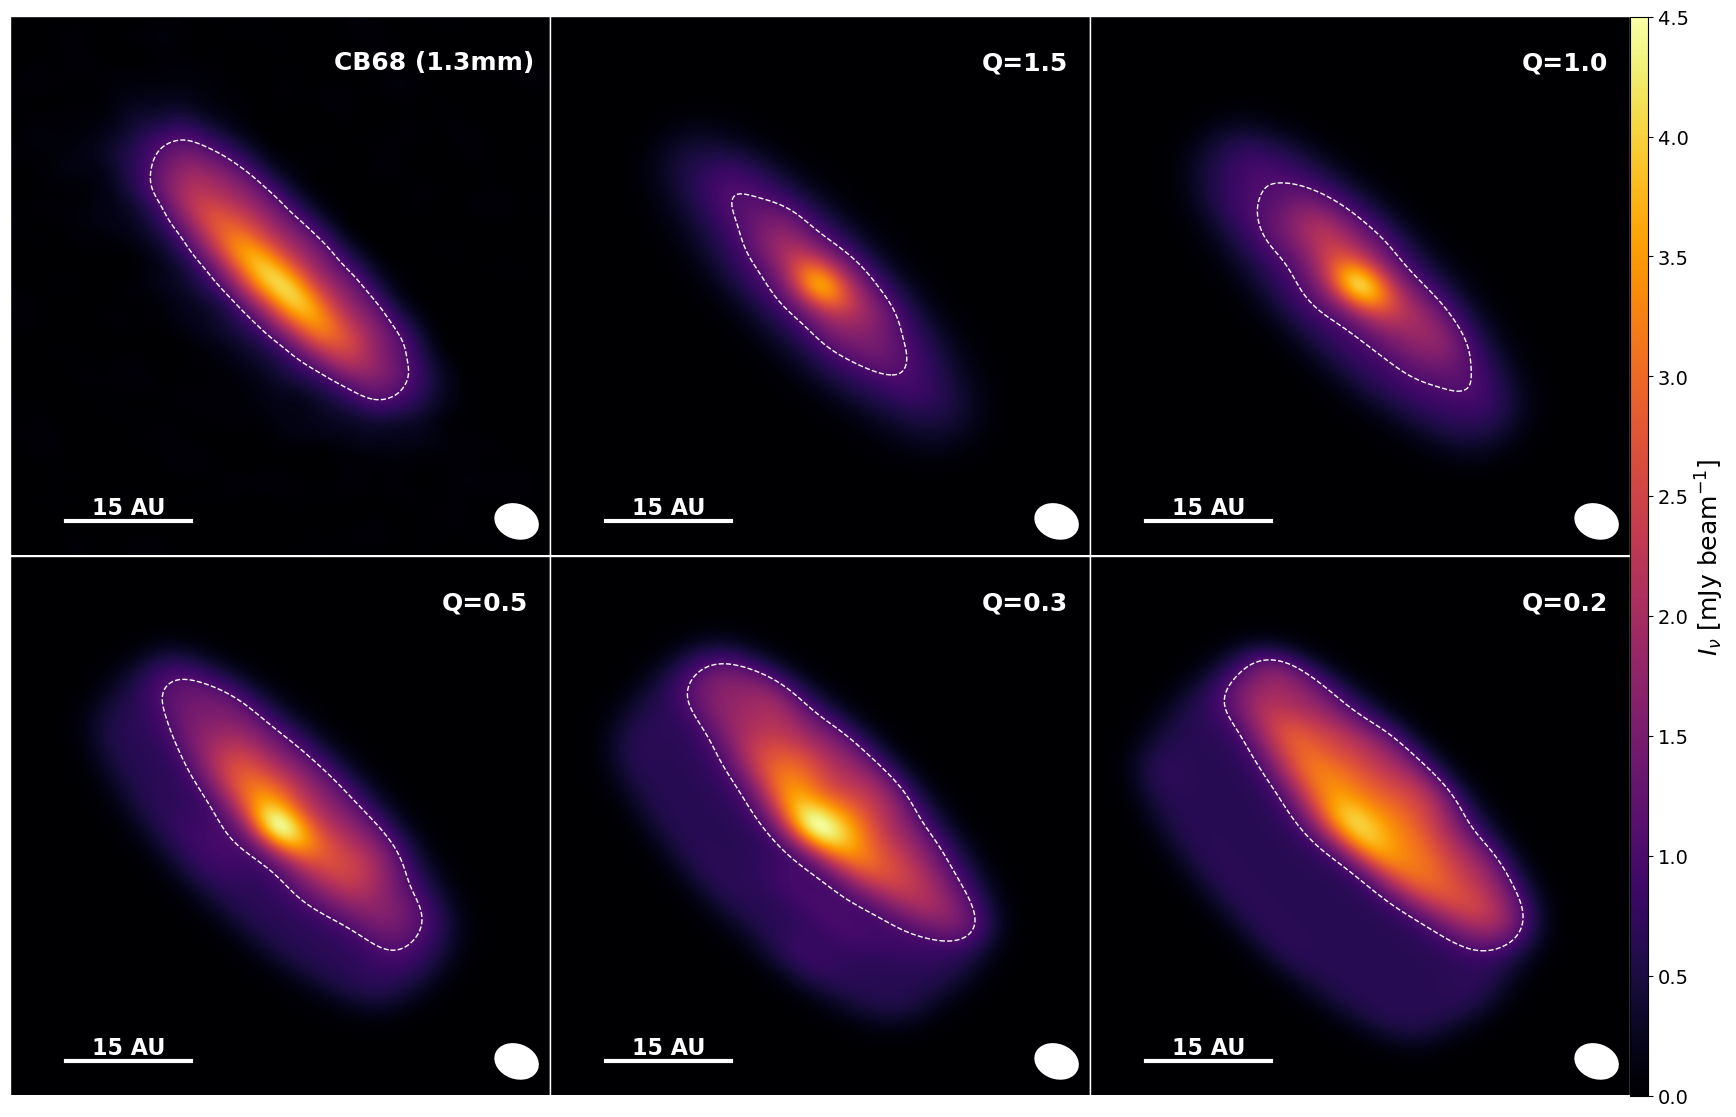

In [22]:
# a_list = [1e-2, 5e-2, 1e-1]
a_list = [5e-2]
L_star_list = [5e0]
Q_list = ["CB68", 1.5, 1, 0.5, 0.3, 0.2]
# Q_list = [0.3, 0.2, 0.1]
# Q_list = [1.5]
# mdot_list = [1e-6]
mdot_list = [1e-7]
# heat_list = ["radiation", "accretion"]
heat_list = ["radiation"]


distance_pc = 140
crop_sizeau = 80
sizeau = crop_sizeau
posang = 45

fits_data = data_dict["1.3_edisk"]
beam_axis = [fits_data["bmaj"], fits_data["bmin"]]
beam_area = beam_axis[0]*beam_axis[1]*np.pi/(4*np.log(2))
beam_pa = fits_data["bpa"]
sigma = fits_data["sigma"]

with fits.open(fits_data["fname"]) as hdul:
    data = hdul[0].data
    header = hdul[0].header
    with warnings.catch_warnings():
        warnings.simplefilter('ignore')
        wcs = WCS(header=header)

au_per_pix_edisk = abs(header['CDELT1'])/180*np.pi*distance_pc*pc/au


edisk_image = crop_image(data, [2996, 2996], crop_sizeau, au_per_pix_edisk)
f_interp_edisk = interp2d(np.linspace(-(crop_sizeau//2), crop_sizeau//2, edisk_image.shape[0]),
                          np.linspace(-(crop_sizeau//2), crop_sizeau//2, edisk_image.shape[1]), edisk_image, kind='linear')
edisk_image = f_interp_edisk(np.linspace(-(crop_sizeau//2), crop_sizeau//2, 1000),
                            np.linspace(-(crop_sizeau//2), crop_sizeau//2, 1000))
peak_idx_x_edisk, peak_idx_y_edisk = np.unravel_index(np.argmax(edisk_image, axis=None), edisk_image.shape)
edisk_image = edisk_image[peak_idx_x_edisk-400:peak_idx_x_edisk+400, peak_idx_y_edisk-400:peak_idx_y_edisk+400]



fig, ax = plt.subplots(2, 3, figsize=(18, 12), sharex=True, sharey=True)
axes = ax.flatten()
# Optional: Set a specific boundary color and width for each subplot
for ax in axes:
    for spine in ax.spines.values():
        spine.set_edgecolor("w")    # or any other color
        spine.set_linewidth(1)         # make the border thicker if desired
fig.subplots_adjust(left=0.05, right=0.95, top=0.95, bottom=0.05, wspace=0, hspace=0)
for idx_a, a in enumerate(a_list):
    for heat in heat_list:
        for idx_mdot, mdot in enumerate(mdot_list):
            for idx_l, L_star in enumerate(L_star_list):
                for idx_q, Q in enumerate(Q_list):
                    if Q == "CB68":
                        cb68 = axes[idx_q].imshow(edisk_image*1e3, origin='lower', cmap="inferno", vmin=0, vmax=4.5)
                        # axes[idx_q].set_title(f"CB68")
                        axes[idx_q].text(0.6, 0.9, f"CB68 (1.3mm)", transform=axes[idx_q].transAxes, color='w', fontweight='bold', fontsize=18)
                        axes[idx_q].plot([175-(15/32*400)//2, 175+(15/32*400)//2], [50, 50], 'w-', lw=3)
                        axes[idx_q].text(175, 60, f"15 AU", color='w', fontsize=16, ha='center', fontweight='bold')
                        axes[idx_q].set_xticks([])
                        axes[idx_q].set_yticks([])
                        axes[idx_q].contour(edisk_image, levels=[50*21e-6], colors='w', linewidths=1, linestyles='dashed')
                        beam = Ellipse((750, 50), height=beam_axis[0]*distance_pc/(32/400), width=beam_axis[1]*distance_pc/(32/400),
                                        angle=beam_pa, edgecolor='w', facecolor='w', lw=2)
                        axes[idx_q].add_patch(beam)
                    else:
                        # model = generate_model(a, L_star, Q, mdot, heat = heat)
                        # os.system(f"make cleanall")
                        model_im = image.readImage(fname=f'./simulation/outfile/conti_a_{a}_Lstar_{L_star}_Q_{Q}_mdot_{mdot}_{heat}_scat.out')
                        npix = model_im.nx
                        pixel_area = (sizeau/npix/140)**2
                        conv_image = model_im.imConv(dpc=140, fwhm=beam_axis, pa=-beam_pa)
                        conv_image = conv_image.imageJyppix * beam_area/pixel_area/(140**2)
                        f_interp_model = interp2d(np.linspace(-(crop_sizeau//2), crop_sizeau//2, conv_image.shape[0]),
                                np.linspace(-(crop_sizeau//2), crop_sizeau//2, conv_image.shape[1]), conv_image, kind='linear')
                        conv_image = f_interp_model(np.linspace(-(crop_sizeau//2), crop_sizeau//2, 1000),
                                                    np.linspace(-(crop_sizeau//2), crop_sizeau//2, 1000))
                        peak_idx_x_model, peak_idx_y_model = np.unravel_index(np.argmax(conv_image, axis=None), conv_image.shape)
                        conv_image = conv_image[peak_idx_x_model-400:peak_idx_x_model+400, peak_idx_y_model-400:peak_idx_y_model+400].T
                        axes[idx_q].imshow(conv_image*1e3, origin='lower', cmap="inferno", vmin=0, vmax=4.5)
                        # axes[idx_q].set_title(f"Q={Q}")
                        axes[idx_q].text(0.8, 0.9, f"Q={float(Q)}", transform=axes[idx_q].transAxes, color='w', fontweight='bold', fontsize=18)
                        axes[idx_q].plot([175-(15/32*400)//2, 175+(15/32*400)//2], [50, 50], 'w-', lw=3)
                        axes[idx_q].text(175, 60, f"15 AU", color='w', fontsize=16, ha='center', fontweight='bold')
                        axes[idx_q].set_xticks([])
                        axes[idx_q].set_yticks([])
                        axes[idx_q].contour(conv_image, levels=[50*21e-6], colors='w', linewidths=1, linestyles='dashed')
                        beam = Ellipse((750, 50), height=beam_axis[0]*distance_pc/(32/400), width=beam_axis[1]*distance_pc/(32/400),
                                        angle=beam_pa, edgecolor='w', facecolor='w', lw=2)
                        axes[idx_q].add_patch(beam)
                cbar_ax = fig.add_axes([0.95, 0.05, 0.01, 0.899])
                cbar = fig.colorbar(cb68, cax=cbar_ax, orientation='vertical', fraction=0.2, pad=0.01)
                cbar.set_label(r'$I_{\nu}$ [mJy beam$^{-1}$]', fontsize=18)
                cbar.ax.tick_params(labelsize=14)

Reading ./simulation/outfile/conti_a_0.05_Lstar_5.0_Q_1.5_mdot_1e-07_radiation_scat.out
Reading ./simulation/outfile/conti_a_0.05_Lstar_5.0_Q_1_mdot_1e-07_radiation_scat.out
Reading ./simulation/outfile/conti_a_0.05_Lstar_5.0_Q_0.5_mdot_1e-07_radiation_scat.out
Reading ./simulation/outfile/conti_a_0.05_Lstar_5.0_Q_0.3_mdot_1e-07_radiation_scat.out
Reading ./simulation/outfile/conti_a_0.05_Lstar_5.0_Q_0.2_mdot_1e-07_radiation_scat.out
Reading ./simulation/outfile/conti_a_0.05_Lstar_5.0_Q_0.1_mdot_1e-07_radiation_scat.out


/tmp/ipykernel_757141/3057472482.py:55: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(labels=[0, 1, 2, 3, 4, 5],fontsize=16)
/tmp/ipykernel_757141/3057472482.py:44: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(labels=[0, 1, 2, 3, 4, 5],fontsize=16)


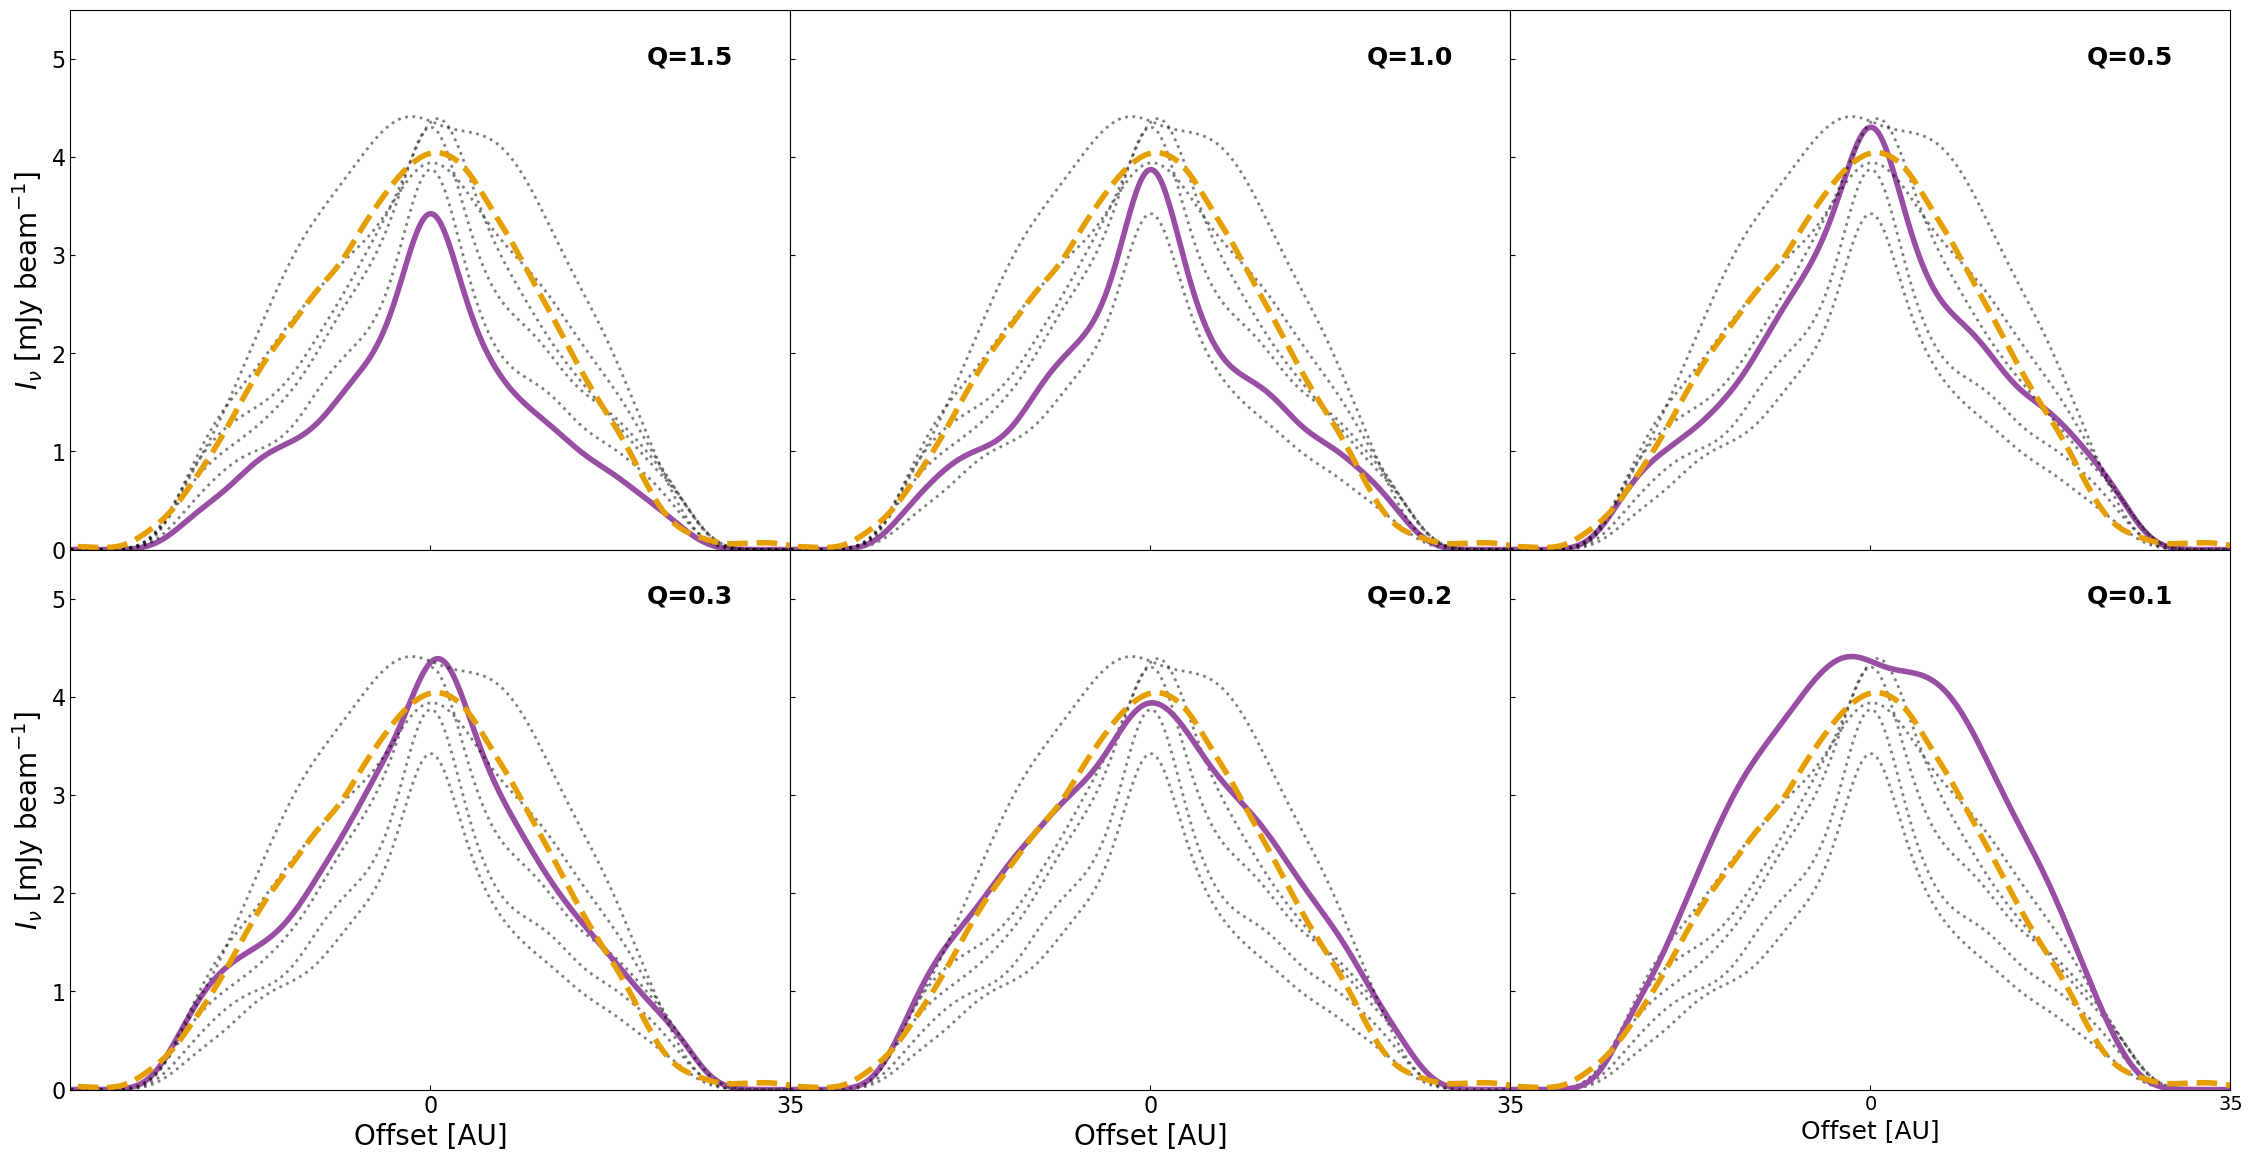

In [28]:
# a_list = [1e-2, 5e-2, 1e-1]
a_list = [5e-2]
L_star_list = [5e0]
Q_list = [1.5, 1, 0.5, 0.3, 0.2, 0.1]
# Q_list = [0.3, 0.2, 0.1]
# Q_list = [1.5]
# mdot_list = [1e-6]
mdot_list = [1e-7]
# heat_list = ["radiation", "accretion"]
heat_list = ["radiation"]

i_r_list = []
for idx_mdot, mdot in enumerate(mdot_list):  
    for heat in heat_list:
        for idx_l, L_star in enumerate(L_star_list):
            for idx_a, a in enumerate(a_list):
                for idx_q, Q in enumerate(Q_list):
                    try:
                        model_im = image.readImage(fname=f'./simulation/outfile/conti_a_{a}_Lstar_{L_star}_Q_{Q}_mdot_{mdot}_{heat}_scat.out')
                    except:
                        model = generate_model(a, L_star, Q, mdot, heat = heat)
                        os.system(f"make cleanall")
                        model_im = image.readImage(fname=f'./simulation/outfile/conti_a_{a}_Lstar_{L_star}_Q_{Q}_mdot_{mdot}_{heat}_scat.out')
                    i_r_model = get_radial_profile(model_im, beam_axis, posang=45, center=None, width=10)
                    i_r_list.append(i_r_model)
color_list = ['#984ea3', '#e69f00']
fig, ax = plt.subplots(2, 3, figsize=(24, 12), sharex=True, sharey=True)
axes = ax.flatten()
fig.subplots_adjust(left=0.05, right=0.95, top=0.95, bottom=0.05, wspace=0, hspace=0)
for idx_ax, ax in enumerate(axes):
    for idx, i_r_plot in enumerate(i_r_list):
        if idx == idx_ax:
            ax.plot(r_axis, i_r_plot*1e3, color='#984ea3', alpha=1, linestyle="-", lw=4)
        else:
            ax.plot(r_axis, i_r_plot*1e3, color='k', alpha=.5, linestyle=":", lw=2)
    ax.plot(edisk_radial["r_axis"], edisk_radial["i_r"]*1e3, linestyle="--", lw=4, color='#e69f00')
    ax.set_ylim(bottom=0, top=5.5)
    ax.set_xlim(left=-35, right=35)
    if idx_ax == 3:
        ax.set_xticks([-35, 0])
        ax.set_xticklabels([-35, 0], fontsize=16)
        ax.set_xlabel("Offset [AU]", fontsize=20)
        ax.set_ylabel(r"$I_{\nu}$ [mJy beam$^{-1}$]", fontsize=20)
        ax.set_yticklabels(labels=[0, 1, 2, 3, 4, 5],fontsize=16)
    if idx_ax == 4:
        ax.set_xticks([0, 35])
        ax.set_xticklabels([-35, 0], fontsize=16)
        ax.set_xlabel("Offset [AU]", fontsize=20)
    if idx_ax == 5:
        ax.set_xticks([0, 35])
        ax.set_xticklabels([0, 35], fontsize=14)
        ax.set_xlabel("Offset [AU]", fontsize=18)
    if idx_ax == 0:
        ax.set_ylabel(r"$I_{\nu}$ [mJy beam$^{-1}$]", fontsize=20)
        ax.set_yticklabels(labels=[0, 1, 2, 3, 4, 5],fontsize=16)
    ax.tick_params(direction="in")
    ax.text(0.8, 0.9, f"Q={float(Q_list[idx_ax])}", transform=ax.transAxes, color='k', fontweight='bold', fontsize=18)

plt.savefig(f"./figures/lowQ_i_r.pdf", transparent=True, bbox_inches='tight')
plt.show()

/tmp/ipykernel_757141/423618949.py:35: DeprecationWarning: `interp2d` is deprecated in SciPy 1.10 and will be removed in SciPy 1.14.0.

For legacy code, nearly bug-for-bug compatible replacements are
`RectBivariateSpline` on regular grids, and `bisplrep`/`bisplev` for
scattered 2D data.

In new code, for regular grids use `RegularGridInterpolator` instead.
For scattered data, prefer `LinearNDInterpolator` or
`CloughTocher2DInterpolator`.

For more details see
`https://scipy.github.io/devdocs/notebooks/interp_transition_guide.html`

  f_interp_edisk = interp2d(np.linspace(-(crop_sizeau//2), crop_sizeau//2, edisk_image.shape[0]),
/tmp/ipykernel_757141/423618949.py:37: DeprecationWarning: `interp2d` is deprecated in SciPy 1.10 and will be removed in SciPy 1.14.0.

For legacy code, nearly bug-for-bug compatible replacements are
`RectBivariateSpline` on regular grids, and `bisplrep`/`bisplev` for
scattered 2D data.

In new code, for regular grids use `RegularGridInterpolator` instead.
For s

Reading ./simulation/outfile/conti_a_0.1_Lstar_0.1_Q_1.5_mdot_1e-07_accretion_scat.out


/tmp/ipykernel_757141/423618949.py:77: DeprecationWarning: `interp2d` is deprecated in SciPy 1.10 and will be removed in SciPy 1.14.0.

For legacy code, nearly bug-for-bug compatible replacements are
`RectBivariateSpline` on regular grids, and `bisplrep`/`bisplev` for
scattered 2D data.

In new code, for regular grids use `RegularGridInterpolator` instead.
For scattered data, prefer `LinearNDInterpolator` or
`CloughTocher2DInterpolator`.

For more details see
`https://scipy.github.io/devdocs/notebooks/interp_transition_guide.html`

  f_interp_model = interp2d(np.linspace(-(crop_sizeau//2), crop_sizeau//2, conv_image.shape[0]),
/tmp/ipykernel_757141/423618949.py:79: DeprecationWarning: `interp2d` is deprecated in SciPy 1.10 and will be removed in SciPy 1.14.0.

For legacy code, nearly bug-for-bug compatible replacements are
`RectBivariateSpline` on regular grids, and `bisplrep`/`bisplev` for
scattered 2D data.

In new code, for regular grids use `RegularGridInterpolator` instead.
For sc

Reading ./simulation/outfile/conti_a_0.1_Lstar_0.1_Q_1_mdot_1e-07_accretion_scat.out
Reading ./simulation/outfile/conti_a_0.1_Lstar_0.1_Q_0.5_mdot_1e-07_accretion_scat.out
Reading ./simulation/outfile/conti_a_0.1_Lstar_0.1_Q_0.3_mdot_1e-07_accretion_scat.out
Reading ./simulation/outfile/conti_a_0.1_Lstar_0.1_Q_0.2_mdot_1e-07_accretion_scat.out


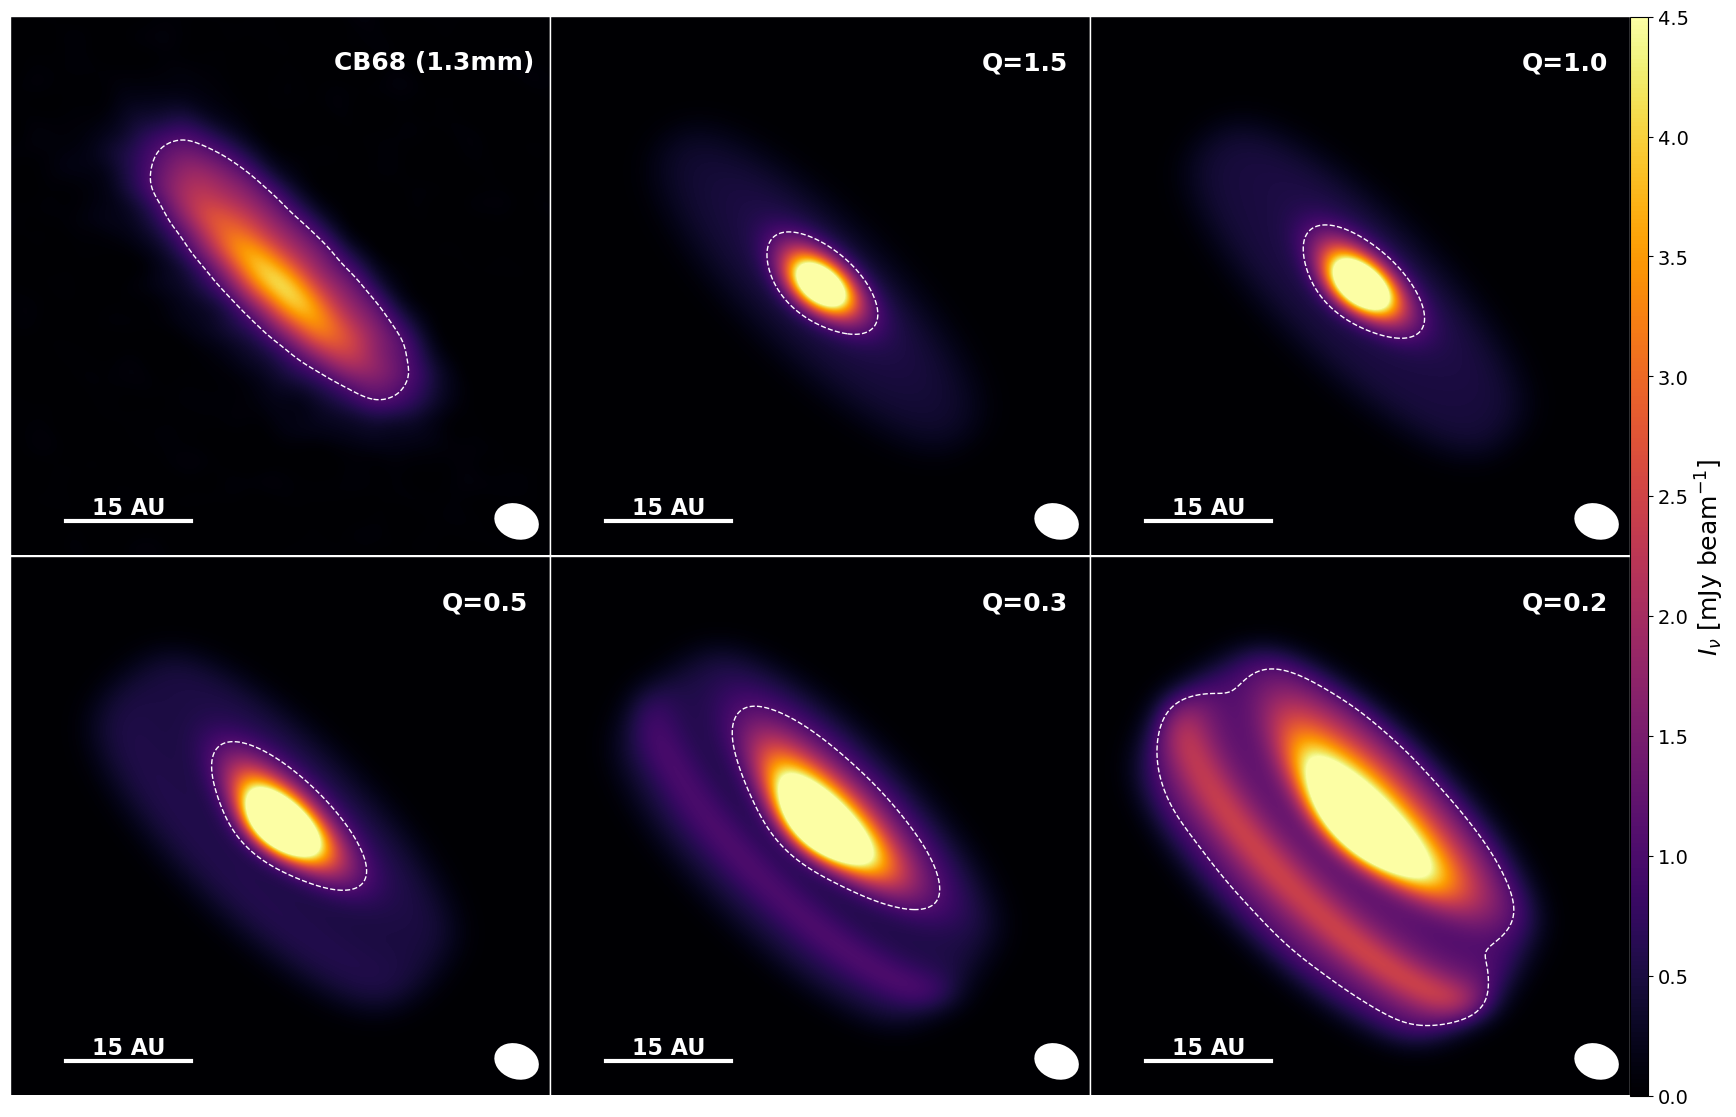

In [19]:
# a_list = [1e-2, 5e-2, 1e-1]
a_list = [1e-1]
L_star_list = [1e-1]
Q_list = ["CB68", 1.5, 1, 0.5, 0.3, 0.2]
# Q_list = [0.3, 0.2, 0.1]
# Q_list = [1.5]
# mdot_list = [1e-6]
mdot_list = [1e-7]
# heat_list = ["radiation", "accretion"]
heat_list = ["accretion"]


distance_pc = 140
crop_sizeau = 80
sizeau = crop_sizeau
posang = 45

fits_data = data_dict["1.3_edisk"]
beam_axis = [fits_data["bmaj"], fits_data["bmin"]]
beam_area = beam_axis[0]*beam_axis[1]*np.pi/(4*np.log(2))
beam_pa = fits_data["bpa"]
sigma = fits_data["sigma"]

with fits.open(fits_data["fname"]) as hdul:
    data = hdul[0].data
    header = hdul[0].header
    with warnings.catch_warnings():
        warnings.simplefilter('ignore')
        wcs = WCS(header=header)

au_per_pix_edisk = abs(header['CDELT1'])/180*np.pi*distance_pc*pc/au


edisk_image = crop_image(data, [2996, 2996], crop_sizeau, au_per_pix_edisk)
f_interp_edisk = interp2d(np.linspace(-(crop_sizeau//2), crop_sizeau//2, edisk_image.shape[0]),
                          np.linspace(-(crop_sizeau//2), crop_sizeau//2, edisk_image.shape[1]), edisk_image, kind='linear')
edisk_image = f_interp_edisk(np.linspace(-(crop_sizeau//2), crop_sizeau//2, 1000),
                            np.linspace(-(crop_sizeau//2), crop_sizeau//2, 1000))
peak_idx_x_edisk, peak_idx_y_edisk = np.unravel_index(np.argmax(edisk_image, axis=None), edisk_image.shape)
edisk_image = edisk_image[peak_idx_x_edisk-400:peak_idx_x_edisk+400, peak_idx_y_edisk-400:peak_idx_y_edisk+400]



fig, ax = plt.subplots(2, 3, figsize=(18, 12), sharex=True, sharey=True)
axes = ax.flatten()
# Optional: Set a specific boundary color and width for each subplot
for ax in axes:
    for spine in ax.spines.values():
        spine.set_edgecolor("w")    # or any other color
        spine.set_linewidth(1)         # make the border thicker if desired
fig.subplots_adjust(left=0.05, right=0.95, top=0.95, bottom=0.05, wspace=0, hspace=0)
for idx_a, a in enumerate(a_list):
    for heat in heat_list:
        for idx_mdot, mdot in enumerate(mdot_list):
            for idx_l, L_star in enumerate(L_star_list):
                for idx_q, Q in enumerate(Q_list):
                    if Q == "CB68":
                        cb68 = axes[idx_q].imshow(edisk_image*1e3, origin='lower', cmap="inferno", vmin=0, vmax=4.5)
                        # axes[idx_q].set_title(f"CB68")
                        axes[idx_q].text(0.6, 0.9, f"CB68 (1.3mm)", transform=axes[idx_q].transAxes, color='w', fontweight='bold', fontsize=18)
                        axes[idx_q].plot([175-(15/32*400)//2, 175+(15/32*400)//2], [50, 50], 'w-', lw=3)
                        axes[idx_q].text(175, 60, f"15 AU", color='w', fontsize=16, ha='center', fontweight='bold')
                        axes[idx_q].set_xticks([])
                        axes[idx_q].set_yticks([])
                        axes[idx_q].contour(edisk_image, levels=[50*21e-6], colors='w', linewidths=1, linestyles='dashed')
                        beam = Ellipse((750, 50), height=beam_axis[0]*distance_pc/(32/400), width=beam_axis[1]*distance_pc/(32/400),
                                        angle=beam_pa, edgecolor='w', facecolor='w', lw=2)
                        axes[idx_q].add_patch(beam)
                    else:
                        # model = generate_model(a, L_star, Q, mdot, heat = heat)
                        # os.system(f"make cleanall")
                        model_im = image.readImage(fname=f'./simulation/outfile/conti_a_{a}_Lstar_{L_star}_Q_{Q}_mdot_{mdot}_{heat}_scat.out')
                        npix = model_im.nx
                        pixel_area = (sizeau/npix/140)**2
                        conv_image = model_im.imConv(dpc=140, fwhm=beam_axis, pa=-beam_pa)
                        conv_image = conv_image.imageJyppix * beam_area/pixel_area/(140**2)
                        f_interp_model = interp2d(np.linspace(-(crop_sizeau//2), crop_sizeau//2, conv_image.shape[0]),
                                np.linspace(-(crop_sizeau//2), crop_sizeau//2, conv_image.shape[1]), conv_image, kind='linear')
                        conv_image = f_interp_model(np.linspace(-(crop_sizeau//2), crop_sizeau//2, 1000),
                                                    np.linspace(-(crop_sizeau//2), crop_sizeau//2, 1000))
                        peak_idx_x_model, peak_idx_y_model = np.unravel_index(np.argmax(conv_image, axis=None), conv_image.shape)
                        conv_image = conv_image[peak_idx_x_model-400:peak_idx_x_model+400, peak_idx_y_model-400:peak_idx_y_model+400].T
                        axes[idx_q].imshow(conv_image*1e3, origin='lower', cmap="inferno", vmin=0, vmax=4.5)
                        # axes[idx_q].set_title(f"Q={Q}")
                        axes[idx_q].text(0.8, 0.9, f"Q={float(Q)}", transform=axes[idx_q].transAxes, color='w', fontweight='bold', fontsize=18)
                        axes[idx_q].plot([175-(15/32*400)//2, 175+(15/32*400)//2], [50, 50], 'w-', lw=3)
                        axes[idx_q].text(175, 60, f"15 AU", color='w', fontsize=16, ha='center', fontweight='bold')
                        axes[idx_q].set_xticks([])
                        axes[idx_q].set_yticks([])
                        axes[idx_q].contour(conv_image, levels=[50*21e-6], colors='w', linewidths=1, linestyles='dashed')
                        beam = Ellipse((750, 50), height=beam_axis[0]*distance_pc/(32/400), width=beam_axis[1]*distance_pc/(32/400),
                                        angle=beam_pa, edgecolor='w', facecolor='w', lw=2)
                        axes[idx_q].add_patch(beam)
                cbar_ax = fig.add_axes([0.95, 0.05, 0.01, 0.899])
                cbar = fig.colorbar(cb68, cax=cbar_ax, orientation='vertical', fraction=0.2, pad=0.01)
                cbar.set_label(r'$I_{\nu}$ [mJy beam$^{-1}$]', fontsize=18)
                cbar.ax.tick_params(labelsize=14)

plt.savefig(f"./figures/lowQ_acc.pdf", transparent=True, bbox_inches='tight')

Reading ./simulation/outfile/conti_a_0.1_Lstar_0.1_Q_1.5_mdot_1e-07_accretion_scat.out
Reading ./simulation/outfile/conti_a_0.1_Lstar_0.1_Q_1_mdot_1e-07_accretion_scat.out
Reading ./simulation/outfile/conti_a_0.1_Lstar_0.1_Q_0.5_mdot_1e-07_accretion_scat.out
Reading ./simulation/outfile/conti_a_0.1_Lstar_0.1_Q_0.3_mdot_1e-07_accretion_scat.out
Reading ./simulation/outfile/conti_a_0.1_Lstar_0.1_Q_0.2_mdot_1e-07_accretion_scat.out
Reading ./simulation/outfile/conti_a_0.1_Lstar_0.1_Q_0.1_mdot_1e-07_accretion_scat.out


/tmp/ipykernel_757141/3452766084.py:56: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(labels=[0, 1, 2, 3, 4, 5],fontsize=16)
/tmp/ipykernel_757141/3452766084.py:45: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(labels=[0, 1, 2, 3, 4, 5],fontsize=16)


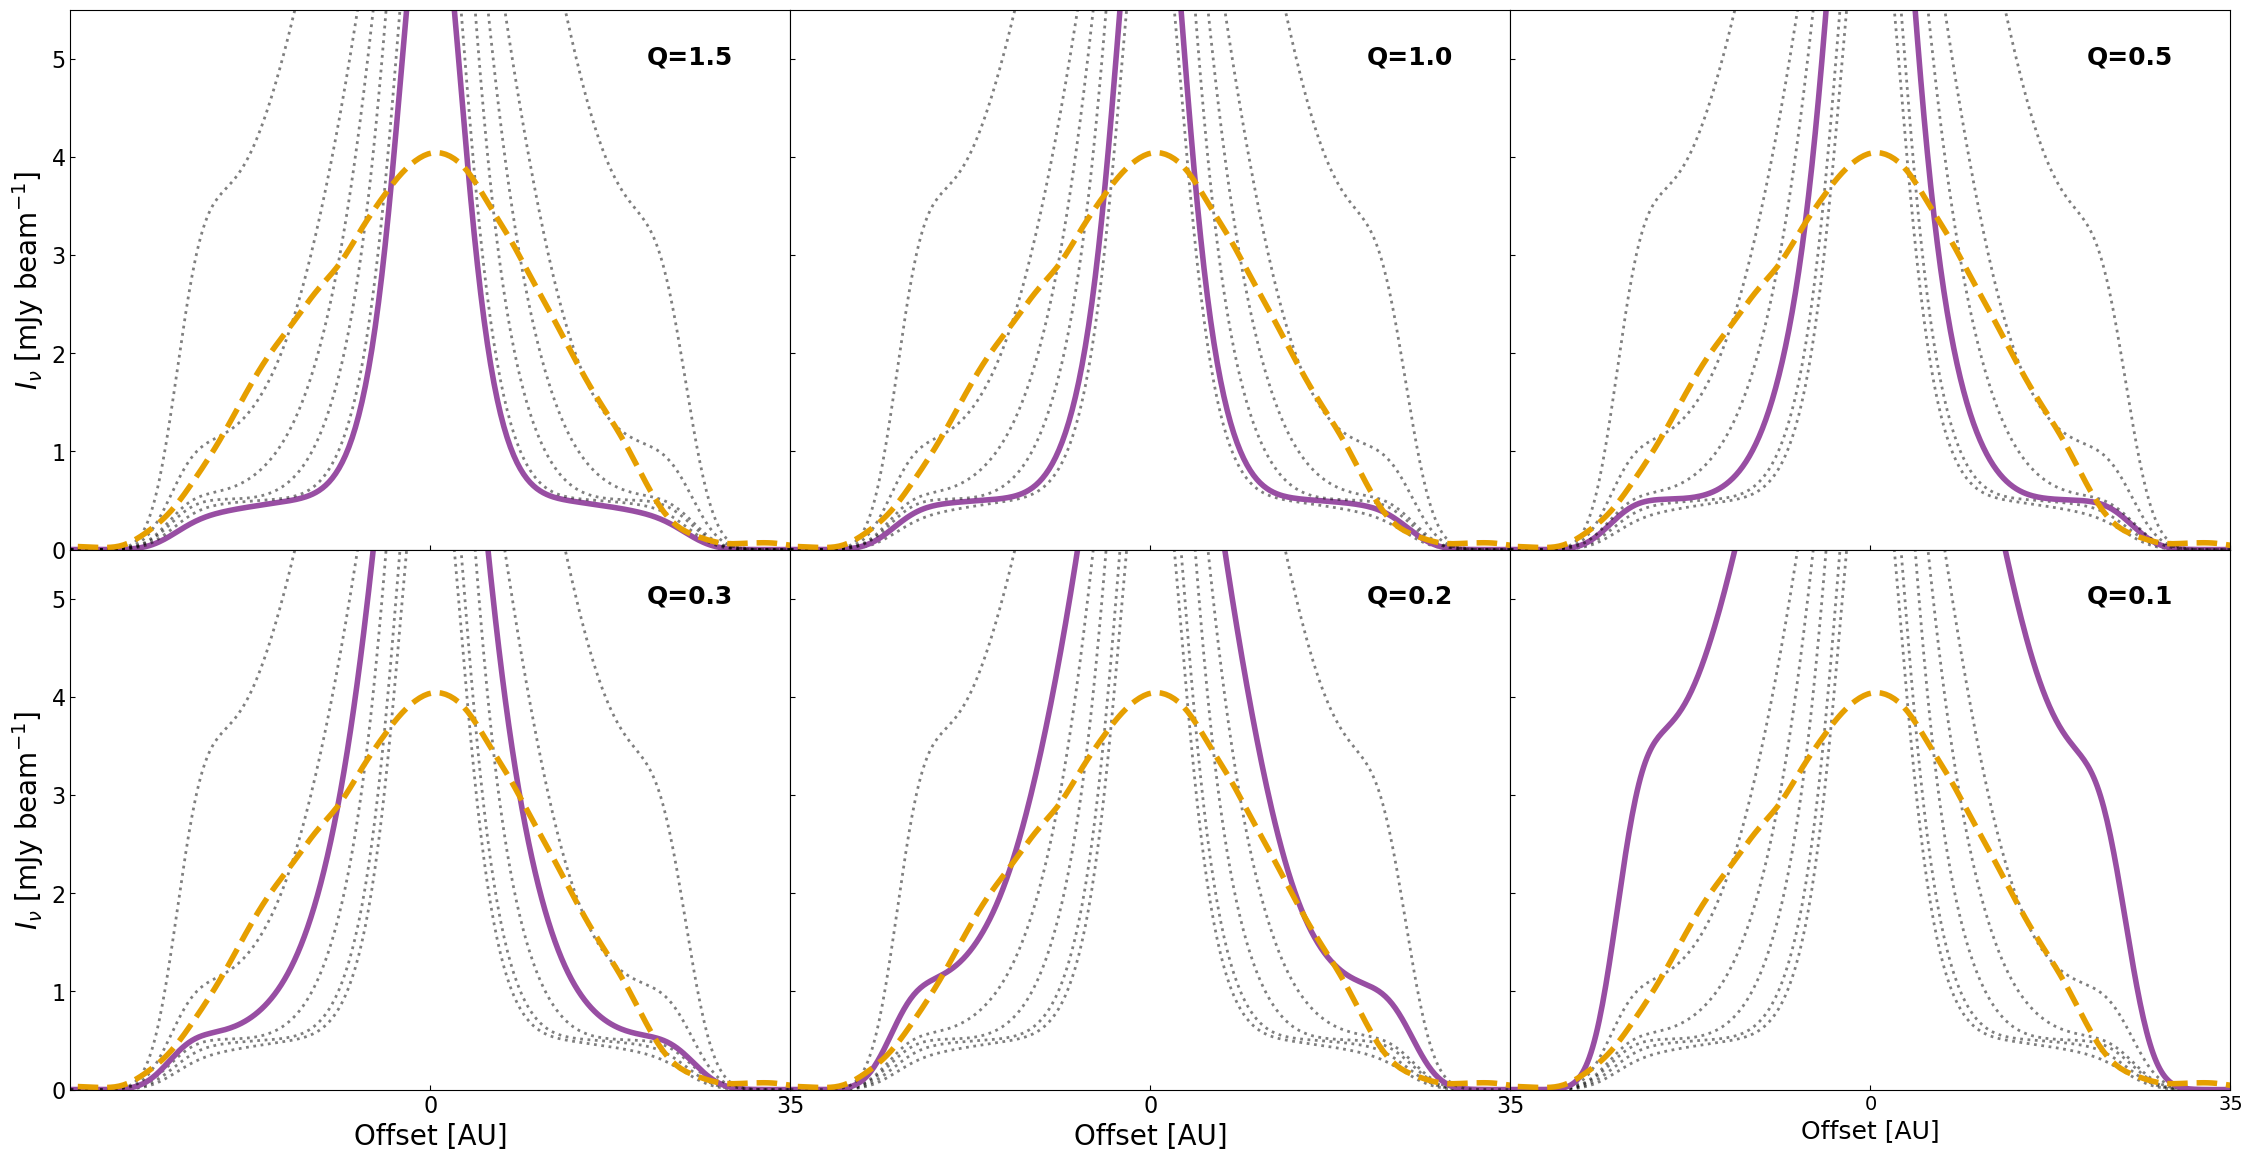

In [21]:
# a_list = [1e-2, 5e-2, 1e-1]
a_list = [1e-1]
L_star_list = [1e-1]
Q_list = [1.5, 1, 0.5, 0.3, 0.2, 0.1]
# Q_list = [0.3, 0.2, 0.1]
# Q_list = [1.5]
# mdot_list = [1e-6]
mdot_list = [1e-7]
# heat_list = ["radiation", "accretion"]
heat_list = ["accretion"]


i_r_list = []
for idx_mdot, mdot in enumerate(mdot_list):  
    for heat in heat_list:
        for idx_l, L_star in enumerate(L_star_list):
            for idx_a, a in enumerate(a_list):
                for idx_q, Q in enumerate(Q_list):
                    try:
                        model_im = image.readImage(fname=f'./simulation/outfile/conti_a_{a}_Lstar_{L_star}_Q_{Q}_mdot_{mdot}_{heat}_scat.out')
                    except:
                        model = generate_model(a, L_star, Q, mdot, heat = heat)
                        os.system(f"make cleanall")
                        model_im = image.readImage(fname=f'./simulation/outfile/conti_a_{a}_Lstar_{L_star}_Q_{Q}_mdot_{mdot}_{heat}_scat.out')
                    i_r_model = get_radial_profile(model_im, beam_axis, posang=45, center=None, width=10)
                    i_r_list.append(i_r_model)
color_list = ['#984ea3', '#e69f00']
fig, ax = plt.subplots(2, 3, figsize=(24, 12), sharex=True, sharey=True)
axes = ax.flatten()
fig.subplots_adjust(left=0.05, right=0.95, top=0.95, bottom=0.05, wspace=0, hspace=0)
for idx_ax, ax in enumerate(axes):
    for idx, i_r_plot in enumerate(i_r_list):
        if idx == idx_ax:
            ax.plot(r_axis, i_r_plot*1e3, color='#984ea3', alpha=1, linestyle="-", lw=4)
        else:
            ax.plot(r_axis, i_r_plot*1e3, color='k', alpha=.5, linestyle=":", lw=2)
    ax.plot(edisk_radial["r_axis"], edisk_radial["i_r"]*1e3, linestyle="--", lw=4, color='#e69f00')
    ax.set_ylim(bottom=0, top=5.5)
    ax.set_xlim(left=-35, right=35)
    if idx_ax == 3:
        ax.set_xticks([-35, 0])
        ax.set_xticklabels([-35, 0], fontsize=16)
        ax.set_xlabel("Offset [AU]", fontsize=20)
        ax.set_ylabel(r"$I_{\nu}$ [mJy beam$^{-1}$]", fontsize=20)
        ax.set_yticklabels(labels=[0, 1, 2, 3, 4, 5],fontsize=16)
    if idx_ax == 4:
        ax.set_xticks([0, 35])
        ax.set_xticklabels([-35, 0], fontsize=16)
        ax.set_xlabel("Offset [AU]", fontsize=20)
    if idx_ax == 5:
        ax.set_xticks([0, 35])
        ax.set_xticklabels([0, 35], fontsize=14)
        ax.set_xlabel("Offset [AU]", fontsize=18)
    if idx_ax == 0:
        ax.set_ylabel(r"$I_{\nu}$ [mJy beam$^{-1}$]", fontsize=20)
        ax.set_yticklabels(labels=[0, 1, 2, 3, 4, 5],fontsize=16)
    ax.tick_params(direction="in")
    ax.text(0.8, 0.9, f"Q={float(Q_list[idx_ax])}", transform=ax.transAxes, color='k', fontweight='bold', fontsize=18)

plt.savefig(f"./figures/lowQ_i_r_acc.pdf", transparent=True, bbox_inches='tight')
plt.show()

In [23]:
a_list = [1e-2, 5e-2, 1e-1, 5e-1, 1e0, 1e1]
# a_list = [1e-1, 1e0, 1e1]
L_star_list = [1e-1, 5e-1, 1e0, 3e0, 5e0, 1e1]
Q_list = [0.1, 0.2, 0.3, 0.5, 1, 1.5]
# mdot_list = [1e-8, 1e-7, 1e-6, 1e-5]
mdot_list = [1e-8, 1e-7, 1e-6, 1e-5]
heat_list = ["radiation", "accretion"]
# heat_list = ["radiation"]

chi_list_irr = []
idx_list_irr = []
gaussian_list_irr = []

chi_list_acc = []
idx_list_acc = []
gaussian_list_acc = []

for idx_a, a in enumerate(a_list):
    for idx_l, L_star in enumerate(L_star_list):
        for idx_q, Q in enumerate(Q_list):
            for idx_mdot, mdot in enumerate(mdot_list):
                for heat in heat_list:
                    try:
                        model_im = image.readImage(fname=f'./simulation/outfile/conti_a_{a}_Lstar_{L_star}_Q_{Q}_mdot_{mdot}_{heat}_scat.out')
                        i_r_model = get_radial_profile(model_im, beam_axis, posang=45, center=None, width=10)
                        plot_i_r(i_r_model, a, L_star, Q, mdot, heat=heat)
                        
                        popt = gaussian_fit(i_r_model, r_axis, extract_index=np.argmin(np.abs(r_axis + 30)))
                        I0_fit, r0_fit, sigma_fit = popt

                        if heat == "radiation":
                            gaussian_list_irr.append((I0_fit, sigma_fit))
                            chi_list_irr.append(chi(i_r_model, edisk_radial["i_r"])*pixel_area/beam_area)
                            idx_list_irr.append((idx_a, idx_l, idx_q, idx_mdot))
                        else:
                            gaussian_list_acc.append((I0_fit, sigma_fit))
                            chi_list_acc.append(chi(i_r_model, edisk_radial["i_r"])*pixel_area/beam_area)
                            idx_list_acc.append((idx_a, idx_l, idx_q, idx_mdot))
                    except:
                        pass
                        # model = generate_model(a, L_star, Q, mdot, heat = heat)
                        # os.system(f"make cleanall")
                        # model_im = image.readImage(fname=f'./simulation/outfile/conti_a_{a}_Lstar_{L_star}_Q_{Q}_mdot_{mdot}_{heat}_scat.out')
                    # model = generate_model(a, L_star, Q, mdot, heat = heat)
                    # model_im = image.readImage(fname=f'./simulation/outfile/conti_a_{a}_Lstar_{L_star}_Q_{Q}_mdot_{mdot}_{heat}_scat.out')
                    # plot_image(model_im, beam_axis, posang=45, a=a, L_star=L_star, Q=Q, mdot=mdot, heat=heat)
                    




Reading ./simulation/outfile/conti_a_0.01_Lstar_0.1_Q_0.1_mdot_1e-08_radiation_scat.out
Reading ./simulation/outfile/conti_a_0.01_Lstar_0.1_Q_0.1_mdot_1e-08_accretion_scat.out
Reading ./simulation/outfile/conti_a_0.01_Lstar_0.1_Q_0.1_mdot_1e-07_radiation_scat.out
Reading ./simulation/outfile/conti_a_0.01_Lstar_0.1_Q_0.1_mdot_1e-07_accretion_scat.out
Reading ./simulation/outfile/conti_a_0.01_Lstar_0.1_Q_0.1_mdot_1e-06_radiation_scat.out
Reading ./simulation/outfile/conti_a_0.01_Lstar_0.1_Q_0.1_mdot_1e-06_accretion_scat.out
Reading ./simulation/outfile/conti_a_0.01_Lstar_0.1_Q_0.1_mdot_1e-05_radiation_scat.out
Reading ./simulation/outfile/conti_a_0.01_Lstar_0.1_Q_0.1_mdot_1e-05_accretion_scat.out
Reading ./simulation/outfile/conti_a_0.01_Lstar_0.1_Q_0.2_mdot_1e-08_radiation_scat.out
Reading ./simulation/outfile/conti_a_0.01_Lstar_0.1_Q_0.2_mdot_1e-08_accretion_scat.out
Reading ./simulation/outfile/conti_a_0.01_Lstar_0.1_Q_0.2_mdot_1e-07_radiation_scat.out
Reading ./simulation/outfile/con

In [24]:
print(idx_list_irr[chi_list_irr.index(min(chi_list_irr))])
a_best_idx, L_star_best_idx, Q_best_idx, mdot_best_idx = idx_list_irr[chi_list_irr.index(min(chi_list_irr))]
a_best = a_list[a_best_idx]
L_star_best = L_star_list[L_star_best_idx]
Q_best = Q_list[Q_best_idx]
mdot_best = mdot_list[mdot_best_idx]
print(f"Maximum grain size: {a_best} mm")
print(f"Stellar luminosity: {L_star_best} Lsun")
print(f"Toomre Q: {Q_best}")
print(f"Mass accretion rate: {mdot_best} Msun/yr")

(2, 3, 0, 1)
Maximum grain size: 0.1 mm
Stellar luminosity: 3.0 Lsun
Toomre Q: 0.1
Mass accretion rate: 1e-07 Msun/yr


In [25]:
print(idx_list_acc[chi_list_acc.index(min(chi_list_acc))])
a_best_idx, L_star_best_idx, Q_best_idx, mdot_best_idx = idx_list_acc[chi_list_acc.index(min(chi_list_acc))]
a_best = a_list[a_best_idx]
L_star_best = L_star_list[L_star_best_idx]
Q_best = Q_list[Q_best_idx]
mdot_best = mdot_list[mdot_best_idx]
print(f"Maximum grain size: {a_best} mm")
print(f"Stellar luminosity: {L_star_best} Lsun")
print(f"Toomre Q: {Q_best}")
print(f"Mass accretion rate: {mdot_best} Msun/yr")

(5, 3, 3, 3)
Maximum grain size: 10.0 mm
Stellar luminosity: 3.0 Lsun
Toomre Q: 0.5
Mass accretion rate: 1e-05 Msun/yr


In [26]:
radiation_labeled = False
accretion_labeled = False


color_list = ['#984ea3', '#e69f00']

plt.figure(figsize=(10, 6))
for idx_l, L_star in enumerate(L_star_list):
    for idx_q, Q in enumerate(Q_list):
        for idx_a, a in enumerate(a_list):
            for idx_mdot, mdot in enumerate(mdot_list):
                for heat in heat_list:
                    idx = (a_list.index(a), L_star_list.index(L_star), Q_list.index(Q), mdot_list.index(mdot))
                    try:
                        if heat == "radiation":
                            i0, sigma = gaussian_list_irr[idx_list_irr.index(idx)]
                            if not radiation_labeled:
                                plt.scatter(sigma, i0*1e3, color=color_list[0], label="Radiation", s=25)
                                radiation_labeled = True
                            else:
                                plt.scatter(sigma, i0*1e3, color=color_list[0], s=25)
                        else:
                            i0, sigma = gaussian_list_acc[idx_list_acc.index(idx)]
                            if not accretion_labeled:
                                plt.scatter(sigma, i0*1e3, color=color_list[1], label='Accretion', s=25)
                                accretion_labeled = True
                            else:
                                plt.scatter(sigma, i0*1e3, color=color_list[1], s=25)
                    except:
                        pass
r_axis_edisk, i_r_edisk = edisk_radial["r_axis"], edisk_radial["i_r"]
popt_edisk = gaussian_fit(i_r_edisk, r_axis_edisk, extract_index=np.argmin(np.abs(r_axis_edisk + 35)))
I0_fit_edisk, r0_fit_edisk, sigma_fit_edisk = popt_edisk
plt.scatter(sigma_fit_edisk, I0_fit_edisk*1e3, color='k', label="CB68", marker='o', s=100)
plt.xlabel(r"$\sigma$ (AU)", fontsize=14)
plt.ylabel(r"$I_{0}$ (mJy/beam)", fontsize=14)
plt.ylim(bottom=0)
plt.xlim(left=0)
# plt.show()
plt.legend(fontsize=12)
plt.title("Comparison of Gaussian fit parameters between different heating mechanisms")
plt.savefig(f"./figures/gaussian_fit.pdf", transparent=True)
plt.close("all")